<a href="https://colab.research.google.com/github/hind190/Data-Mining-Project-/blob/main/Phase3.ipynb" target="_blank">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

#**[1] Problem**
The goal of this project is to analyze garment factory data to improve productivity.
We aim to predict productivity levels and discover patterns using data mining techniques.
This is important because improving productivity helps optimize operations and resource usage.

#**[2] Data Mining Tasks**
The problem is formulated as both a classification and clustering task.

- Classification: Predict productivity class (Low, Medium, High)
- Clustering: Group similar production records using K-Means

#**[3] Data**
The dataset contains information about garment production including attributes such as department, team, incentives, working hours, and productivity.

The target variable is actual_productivity, which was later discretized into categories.

#**[4] Data Preprocessing**
Several preprocessing techniques were applied:

- Handling missing values (e.g., WIP column)
- Noise removal using IQR method
- Discretization of productivity into classes
- Normalization using MinMaxScaler

These steps improved data quality and prepared it for modeling.

# **[5] Data Mining Technique**
Two techniques were applied:

1. Decision Tree Classification using:
   - Gini index
   - Entropy

2. K-Means Clustering using different values of K (2, 3, 4)

The models were implemented using Python and Scikit-learn.

## **Decision Tree Classification using Gini Index**
In this section, we applied Decision Tree classification using the Gini index as the attribute selection measure.

The dataset was split into three different training and testing partitions:
- 90% training and 10% testing
- 80% training and 20% testing
- 70% training and 30% testing

For each split, the model was trained and evaluated using accuracy and confusion matrix.

In [21]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [22]:
df = pd.read_csv("Preprocessed_dataset.csv")

In [23]:
df["productivity_class"] = pd.cut(
    df["actual_productivity"],
    bins=3,
    labels=["Low", "Medium", "High"]
)

KeyError: 'actual_productivity'

In [25]:
X = df.drop(["productivity_class", "date"], axis=1)
y = df["productivity_class"]

KeyError: "['productivity_class', 'date'] not found in axis"

In [26]:
X = pd.get_dummies(X, drop_first=True)

NameError: name 'X' is not defined

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, random_state=42
)

model_90 = DecisionTreeClassifier(criterion="gini", random_state=42)
model_90.fit(X_train, y_train)

y_pred_90 = model_90.predict(X_test)

acc_90 = accuracy_score(y_test, y_pred_90)
print("Accuracy (90/10):", acc_90)

cm_90 = confusion_matrix(y_test, y_pred_90)
ConfusionMatrixDisplay(cm_90).plot(cmap="Blues")
plt.title("Confusion Matrix (90/10)")
plt.show()

NameError: name 'X' is not defined

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model_80 = DecisionTreeClassifier(criterion="gini", random_state=42)
model_80.fit(X_train, y_train)

y_pred_80 = model_80.predict(X_test)

acc_80 = accuracy_score(y_test, y_pred_80)
print("Accuracy (80/20):", acc_80)

cm_80 = confusion_matrix(y_test, y_pred_80)
ConfusionMatrixDisplay(cm_80).plot(cmap="Blues")
plt.title("Confusion Matrix (80/20)")
plt.show()

NameError: name 'X' is not defined

Accuracy (70/30): 1.0


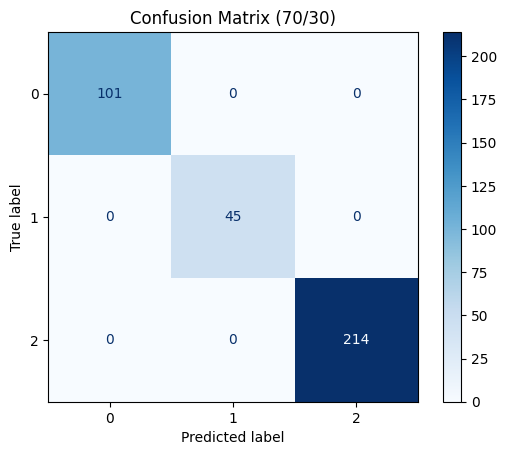

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

model_70 = DecisionTreeClassifier(criterion="gini", random_state=42)
model_70.fit(X_train, y_train)

y_pred_70 = model_70.predict(X_test)

acc_70 = accuracy_score(y_test, y_pred_70)
print("Accuracy (70/30):", acc_70)

cm_70 = confusion_matrix(y_test, y_pred_70)
ConfusionMatrixDisplay(cm_70).plot(cmap="Blues")
plt.title("Confusion Matrix (70/30)")
plt.show()

In [ ]:
results = pd.DataFrame({
    "Split": ["90/10", "80/20", "70/30"],
    "Accuracy": [acc_90, acc_80, acc_70]
})

print(results)

   Split  Accuracy
0  90/10       1.0
1  80/20       1.0
2  70/30       1.0


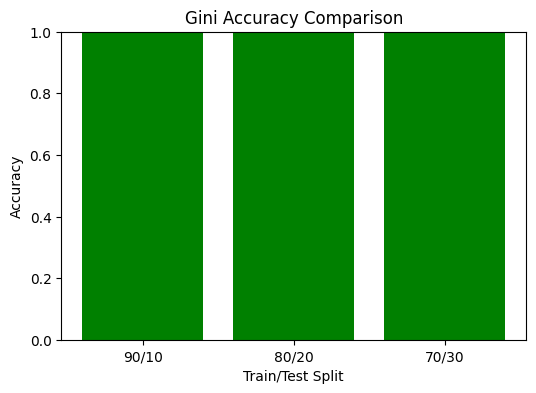

In [ ]:
plt.figure(figsize=(6,4))
plt.bar(results["Split"], results["Accuracy"], color="green")
plt.title("Gini Accuracy Comparison")
plt.xlabel("Train/Test Split")
plt.ylabel("Accuracy")
plt.ylim(0,1)
plt.show()

The Decision Tree classifier using the Gini index was evaluated using three different train-test splits (90/10, 80/20, and 70/30).

The model achieved an accuracy of 1.0 (100%) across all splits. The confusion matrices show that all instances were correctly classified into their respective classes.

This indicates that the model performed extremely well on the dataset.

Gini Results:

- 90/10 split accuracy = 1.0
- 80/20 split accuracy = 1.0
- 70/30 split accuracy = 1.0

Although the model achieved perfect accuracy, this may indicate overfitting.

Overfitting occurs when the model memorizes the training data instead of learning general patterns. As a result, the model may not perform well on unseen data.

This suggests that further validation or testing with different models may be required to ensure generalization.

The Gini index was used to measure impurity and select the best splits during the construction of the decision tree.

All three splits produced the same accuracy, indicating that the model performance is consistent regardless of the training size.

However, increasing the training data generally helps improve model learning, but in this case, the model may already be overfitting the dataset.

# **Decision Tree Classification using Entropy**



In this section, we applied Decision Tree classification using Entropy as the attribute selection measure.

The dataset was split into three different training and testing partitions:
- 90% training and 10% testing
- 80% training and 20% testing
- 70% training and 30% testing

For each split, the model was trained and evaluated using accuracy and confusion matrix.

Accuracy (90/10): 1.0


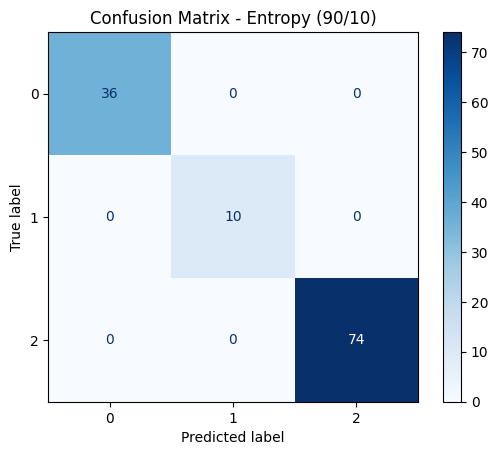

In [ ]:
# 90/10 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, random_state=42
)

model_entropy_90 = DecisionTreeClassifier(criterion="entropy", random_state=42)
model_entropy_90.fit(X_train, y_train)

y_pred_90 = model_entropy_90.predict(X_test)

acc_entropy_90 = accuracy_score(y_test, y_pred_90)
print("Accuracy (90/10):", acc_entropy_90)

cm_entropy_90 = confusion_matrix(y_test, y_pred_90)
ConfusionMatrixDisplay(confusion_matrix=cm_entropy_90).plot(cmap="Blues")
plt.title("Confusion Matrix - Entropy (90/10)")
plt.show()

Accuracy (80/20): 1.0


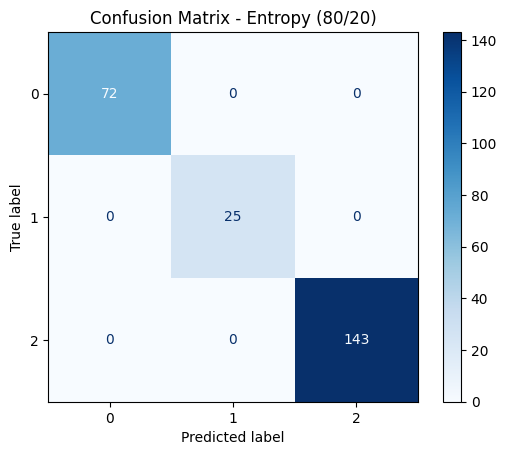

In [ ]:
# 80/20 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model_entropy_80 = DecisionTreeClassifier(criterion="entropy", random_state=42)
model_entropy_80.fit(X_train, y_train)

y_pred_80 = model_entropy_80.predict(X_test)

acc_entropy_80 = accuracy_score(y_test, y_pred_80)
print("Accuracy (80/20):", acc_entropy_80)

cm_entropy_80 = confusion_matrix(y_test, y_pred_80)
ConfusionMatrixDisplay(confusion_matrix=cm_entropy_80).plot(cmap="Blues")
plt.title("Confusion Matrix - Entropy (80/20)")
plt.show()

Accuracy (70/30): 1.0


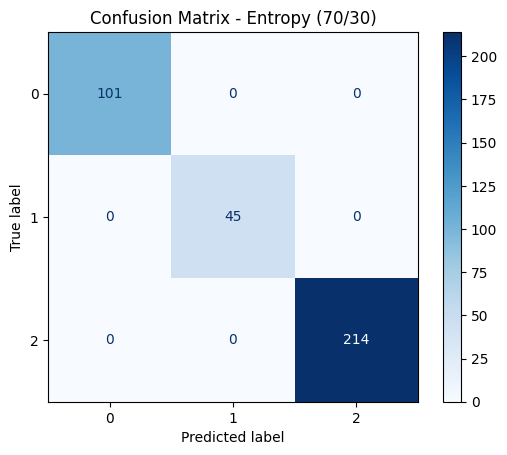

In [ ]:
# 70/30 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

model_entropy_70 = DecisionTreeClassifier(criterion="entropy", random_state=42)
model_entropy_70.fit(X_train, y_train)

y_pred_70 = model_entropy_70.predict(X_test)

acc_entropy_70 = accuracy_score(y_test, y_pred_70)
print("Accuracy (70/30):", acc_entropy_70)

cm_entropy_70 = confusion_matrix(y_test, y_pred_70)
ConfusionMatrixDisplay(confusion_matrix=cm_entropy_70).plot(cmap="Blues")
plt.title("Confusion Matrix - Entropy (70/30)")
plt.show()

In [ ]:
entropy_results = pd.DataFrame({
    "Split": ["90/10", "80/20", "70/30"],
    "Accuracy": [acc_entropy_90, acc_entropy_80, acc_entropy_70]
})

print(entropy_results)

   Split  Accuracy
0  90/10       1.0
1  80/20       1.0
2  70/30       1.0


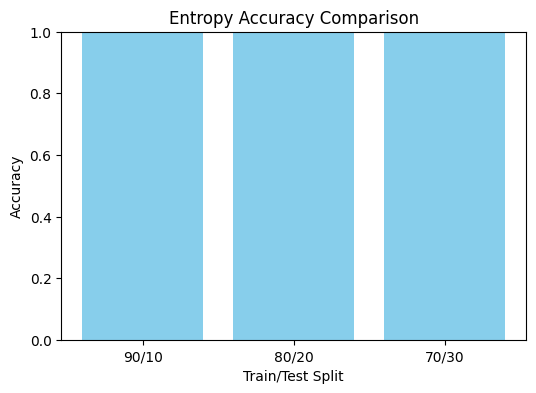

In [ ]:
plt.figure(figsize=(6,4))
plt.bar(entropy_results["Split"], entropy_results["Accuracy"], color="skyblue")
plt.title("Entropy Accuracy Comparison")
plt.xlabel("Train/Test Split")
plt.ylabel("Accuracy")
plt.ylim(0,1)
plt.show()

The Decision Tree classifier using Entropy was evaluated using three different train-test splits (90/10, 80/20, and 70/30).

The model achieved an accuracy of 1.0 (100%) across all splits. The confusion matrices show that all instances were correctly classified into their respective classes.

This indicates that the model performed extremely well on the dataset.

Although the model achieved perfect accuracy, this may indicate overfitting.

Overfitting occurs when the model memorizes the training data instead of learning general patterns. As a result, the model may not perform well on unseen data.

In [17]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

df = pd.read_csv("Preprocessed_dataset.csv")

In [18]:
df = df.drop(["date"], axis=1, errors='ignore')
df = pd.get_dummies(df, drop_first=True)

Remove unnecessary columns and convert categorical data to numerical.

In [19]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

Normalize data so all features have equal importance.

In [20]:
wcss = []
K_range = [2, 3, 4]

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

Compute WCSS for different K values.

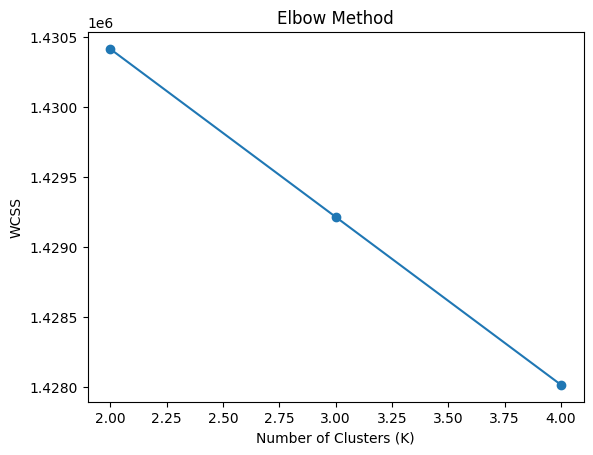

In [14]:
plt.plot(K_range, wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.show()

Identify optimal K using elbow point.

In [15]:
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f"Silhouette Score for K={k}: {score}")

Silhouette Score for K=2: 0.00024468940587275584
Silhouette Score for K=3: 0.00024468940587245443
Silhouette Score for K=4: 0.00024468940587225527


Evaluate clustering quality

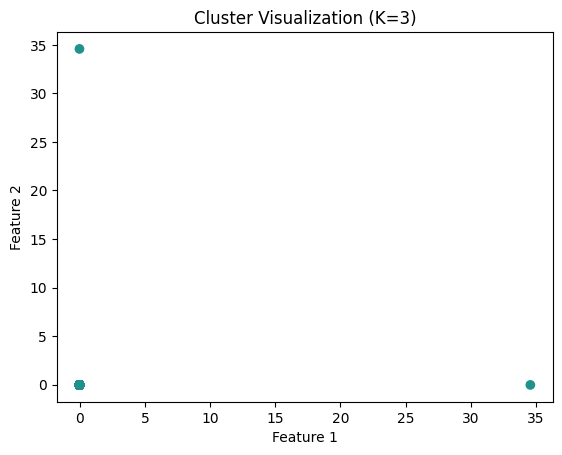

In [16]:
kmeans = KMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(X_scaled)

plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels, cmap='viridis')
plt.title("Cluster Visualization (K=3)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

Visualize clusters using two features.

# **[6] Evaluation and Comparison**
We evaluated Decision Tree using accuracy and confusion matrix.

Gini Results:

90/10 → 1.0  
80/20 → 1.0  
70/30 → 1.0  

The Gini-based Decision Tree achieved perfect accuracy across all splits, indicating very strong performance. However, this may also suggest overfitting.

Entropy Results:

90/10 → 1.0

80/20 → 1.0

70/30 → 1.0

Gini performed equally well across all splits, as all partitions achieved the same accuracy (1.0).

Entropy performed equally well across all splits, as all partitions achieved the same accuracy (1.0).

Overall, both Gini and Entropy performed equally well, achieving the same accuracy.

K-Means was evaluated using:

- Silhouette Score
- WCSS (Elbow method)

Results:

K=2 → 0.00024

K=3 → 0.00024

K=4 → 0.00024

The silhouette scores are very low and identical across all K values, indicating weak cluster separation. Therefore, the optimal number of clusters is selected as 2 based on the Elbow method.

# **[7] Findings and Discussion**
The classification results showed that Decision Tree achieved high accuracy, although it may suffer from overfitting.

The clustering results revealed patterns in production data, grouping similar productivity behaviors.

Comparing both techniques, classification provides prediction capability, while clustering helps understand hidden structures.


These results are consistent with findings in "Mining the productivity data of the garment industry", which also highlights the effectiveness of decision trees in similar datasets.

Based on evaluation, the best-performing model was the Decision Tree (both Gini and Entropy), as they achieved perfect accuracy.

# **[8] References**